# Comparação de Modelos de Sobrevivência
## Case Declínio de SKU - Grupo Boticário

**Modelos comparados:**
1. Cox Proportional Hazards (linear, interpretável)
2. Random Survival Forest (bagging, robusto)
3. Gradient Boosting Survival (boosting, performático)

**Evento:** % pico < 20% + ciclos desde pico >= 15 + PDVs caindo (janela 4 ciclos)

**Métrica:** C-Index (concordância)

**Autor:** Gustavo

---
## 1. Setup

In [1]:
!pip install scikit-survival -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 16.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.nonparametric import kaplan_meier_estimator

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

FIGURES_DIR = '/content/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
HORIZONTE = 25
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


---
## 2. Carregamento e Tratamento

In [3]:
from google.colab import drive
drive.mount('/content/drive')

filepath = '/content/drive/MyDrive/Case SKU/data/base-de-dados.csv'
df = pd.read_csv(filepath, thousands='.')
print(f'Dados: {df.shape[0]} linhas x {df.shape[1]} colunas')

Mounted at /content/drive
Dados: 126781 linhas x 22 colunas


In [4]:
cols_object = df.select_dtypes(include=['object']).columns.tolist()
cols_excluir = ['sk_produto_case','cod_canal_portfolio','des_categoria_portfolio','des_status_atual_agrup']
for col in cols_object:
    if col not in cols_excluir:
        amostra = df[col].dropna().head(100).astype(str)
        if amostra.str.match(r'^[\d\s\.\,\-\+R\$%]+$').mean() > 0.7:
            serie = df[col].astype(str).str.strip().str.replace('.','',regex=False).str.replace(',','.',regex=False)
            df[col] = pd.to_numeric(serie, errors='coerce')
print('Tratamento concluído!')

Tratamento concluído!


---
## 3. Evento e Preparação

In [6]:
ciclos_ordenados = sorted(df['cod_ciclo'].unique())
mapa_ciclo = {ciclo: idx for idx, ciclo in enumerate(ciclos_ordenados)}
df['ordem_ciclo'] = df['cod_ciclo'].map(mapa_ciclo)

def definir_evento_declinio_v2(df, janela=4):
    df = df.sort_values(['sk_produto_case', 'cod_ciclo'])
    group = df.groupby('sk_produto_case')
    df['slope_cpfs_total'] = group['ind_cpfs_total'].diff()
    df['pico_historico'] = group['ind_vlr_receita_real_dia_corrigido'].transform(lambda x: x.expanding().max())
    df['perc_do_pico'] = df['ind_vlr_receita_real_dia_corrigido'] / df['pico_historico'].replace(0, np.nan)
    def calc_ciclos_desde_pico(serie):
        resultado = []
        pico_val = -np.inf
        ciclo_pico = 0
        for i, val in enumerate(serie):
            if val >= pico_val:
                pico_val = val
                ciclo_pico = i
            resultado.append(i - ciclo_pico)
        return pd.Series(resultado, index=serie.index)
    df['ciclos_desde_pico'] = group['ind_vlr_receita_real_dia_corrigido'].transform(calc_ciclos_desde_pico)
    df['sinal_declinio_robusto'] = ((df['perc_do_pico'] < 0.20) & (df['ciclos_desde_pico'] >= 15) & (df['slope_cpfs_total'] < 0)).astype(int)
    df['evento_declinio'] = group['sinal_declinio_robusto'].transform(lambda x: x.rolling(window=janela).sum() >= (janela - 1)).astype(int)
    return df

df = definir_evento_declinio_v2(df, janela=4)

def calc_tempo(grupo):
    primeiro = grupo['ordem_ciclo'].min()
    eventos = grupo[grupo['evento_declinio']==1]['ordem_ciclo']
    if len(eventos) > 0:
        return pd.Series({'duracao': max(eventos.min()-primeiro+1, 1), 'evento': True})
    return pd.Series({'duracao': max(grupo['ordem_ciclo'].max()-primeiro+1, 1), 'evento': False})

vida_produto = df.groupby('sk_produto_case').apply(calc_tempo).reset_index()
vida_produto['evento'] = vida_produto['evento'].astype(bool)
vida_produto['duracao'] = vida_produto['duracao'].astype(float)

print(f'Produtos: {len(vida_produto)}')
print(f'Com evento: {vida_produto["evento"].sum()} ({vida_produto["evento"].mean()*100:.1f}%)')

Produtos: 2462
Com evento: 1230 (50.0%)


---
## 4. Feature Engineering

In [10]:
vars_base = ['ind_cpfs_novos','ind_cpfs_total','ind_vlr_receita_real_dia_corrigido','ind_vlr_receita_real_corrigido','ind_vlr_ruptura','ind_qtd_ciclos_agrupador']
vars_base = [v for v in vars_base if v in df.columns]
df_sorted = df.sort_values(['sk_produto_case','ordem_ciclo'])
df_sorted['flag_ruptura'] = (df_sorted['ind_vlr_ruptura'] > 0).astype(int)
df_sorted['receita_por_cpf'] = df_sorted['ind_vlr_receita_real_dia_corrigido'] / df_sorted['ind_cpfs_total'].replace(0,np.nan)
df_ultimos5 = df_sorted.groupby('sk_produto_case').tail(5)
df_ultimos10 = df_sorted.groupby('sk_produto_case').tail(10)

def calc_ciclos_desde_pico(serie):
    resultado = []
    pico_val = -np.inf
    ciclo_pico = 0
    for i, val in enumerate(serie):
        if val >= pico_val:
            pico_val = val
            ciclo_pico = i
        resultado.append(i - ciclo_pico)
    return pd.Series(resultado, index=serie.index)

def calc_slope(g, v):
    x = np.arange(len(g)); y = g[v].values
    mask = ~np.isnan(y)
    if mask.sum() >= 3: return stats.linregress(x[mask],y[mask])[0]
    return 0

vars_slope = ['ind_cpfs_novos','ind_cpfs_total','ind_vlr_receita_real_dia_corrigido','ind_vlr_ruptura']
vars_slope = [v for v in vars_slope if v in df.columns]
slopes_5 = {f'{v}_slope_ult5': df_ultimos5.groupby('sk_produto_case').apply(lambda g,v=v: calc_slope(g,v)) for v in vars_slope}
feat_slope_5 = pd.DataFrame(slopes_5)
slopes_10 = {f'{v}_slope_ult10': df_ultimos10.groupby('sk_produto_case').apply(lambda g,v=v: calc_slope(g,v)) for v in vars_slope}
feat_slope_10 = pd.DataFrame(slopes_10)
feat_media = df_sorted.groupby('sk_produto_case')[vars_base].mean()
feat_media.columns = [f'{c}_media' for c in feat_media.columns]
feat_ticket = df_sorted.groupby('sk_produto_case')['receita_por_cpf'].mean().reset_index(name='ticket_medio_media')
feat_ticket_slope = df_sorted.groupby('sk_produto_case').apply(lambda g: calc_slope(g,'receita_por_cpf')).rename('ticket_medio_slope').reset_index()
ruptura_ult10 = df_ultimos10.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='prop_ruptura_ult10')
ruptura_global = df_sorted.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='prop_ruptura')

feat_idade = pd.DataFrame({'sk_produto_case': df['sk_produto_case'].unique()})
if 'cod_phase_in_agrup' in df.columns:
    df['ordem_phase_in'] = df['cod_phase_in_agrup'].map(mapa_ciclo)
    pi = df.groupby('sk_produto_case')['ordem_phase_in'].first().reset_index()
    ult = df.groupby('sk_produto_case')['ordem_ciclo'].max().reset_index(name='ult_obs')
    feat_idade = feat_idade.merge(pi, on='sk_produto_case', how='left')
    feat_idade = feat_idade.merge(ult, on='sk_produto_case', how='left')
    feat_idade['idade_produto'] = feat_idade['ult_obs'] - feat_idade['ordem_phase_in']
    feat_idade = feat_idade.drop(columns=['ordem_phase_in','ult_obs'], errors='ignore')


df_sorted['pico_hist'] = df_sorted.groupby('sk_produto_case')['ind_vlr_receita_real_dia_corrigido'].transform(lambda x: x.expanding().max())
df_sorted['pct_pico'] = df_sorted['ind_vlr_receita_real_dia_corrigido'] / df_sorted['pico_hist'].replace(0,np.nan)
df_sorted['ciclos_desde_pico'] = df_sorted.groupby('sk_produto_case')['ind_vlr_receita_real_dia_corrigido'].transform(calc_ciclos_desde_pico)
feat_pico = df_sorted.groupby('sk_produto_case').tail(1)[['sk_produto_case','pct_pico','ciclos_desde_pico']].copy()
feat_pico.columns = ['sk_produto_case','pct_pico_atual','ciclos_desde_pico_atual']

feat_aceleracao = feat_slope_5.reset_index().merge(feat_slope_10.reset_index(), on='sk_produto_case', how='left')
for var in vars_slope:
    feat_aceleracao[f'{var}_aceleracao'] = feat_aceleracao[f'{var}_slope_ult5'] - feat_aceleracao[f'{var}_slope_ult10']
feat_aceleracao = feat_aceleracao[['sk_produto_case'] + [c for c in feat_aceleracao.columns if '_aceleracao' in c]]

vars_mm = ['ind_cpfs_novos','ind_cpfs_total','ind_vlr_receita_real_dia_corrigido']
vars_mm = [v for v in vars_mm if v in df.columns]
for var in vars_mm:
    df_sorted[f'{var}_mm3'] = df_sorted.groupby('sk_produto_case')[var].transform(lambda x: x.rolling(3,min_periods=1).mean())
    df_sorted[f'{var}_mm5'] = df_sorted.groupby('sk_produto_case')[var].transform(lambda x: x.rolling(5,min_periods=1).mean())
cols_mm = [c for c in df_sorted.columns if '_mm3' in c or '_mm5' in c]
feat_mm = df_sorted.groupby('sk_produto_case')[cols_mm].last().reset_index()

feat_lags = pd.DataFrame({'sk_produto_case': df['sk_produto_case'].unique()})
for var in ['ind_vlr_receita_real_dia_corrigido','ind_cpfs_novos','ind_cpfs_total']:
    if var in df.columns:
        ultimo = df_sorted.groupby('sk_produto_case')[var].last().reset_index(name=f'{var}_ultimo')
        feat_lags = feat_lags.merge(ultimo, on='sk_produto_case', how='left')

print('Features criadas!')

Features criadas!


---
## 5. Dataset e Split

In [11]:
df_surv = vida_produto[['sk_produto_case','duracao','evento']].copy()
df_surv = df_surv.merge(feat_media.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_5.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_10.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket_slope, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura_ult10, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura_global, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_idade, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_pico, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_aceleracao, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_mm, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_lags, on='sk_produto_case', how='left')

feature_cols = [c for c in df_surv.columns if c not in ['sk_produto_case','duracao','evento']]
df_surv[feature_cols] = df_surv[feature_cols].replace([np.inf,-np.inf], np.nan)
df_surv[feature_cols] = df_surv[feature_cols].fillna(df_surv[feature_cols].median())

X = df_surv[feature_cols].values
y = np.array([(e,d) for e,d in zip(df_surv['evento'],df_surv['duracao'])], dtype=[('evento',bool),('duracao',float)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=df_surv['evento'].astype(int))
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Dataset: {len(df_surv)} produtos | {len(feature_cols)} features')
print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

Dataset: 2462 produtos | 34 features
Treino: 1846 | Teste: 616


---
## 6. Treinamento e Comparação dos 3 Modelos

In [12]:
# ============================================================
# COMPARAÇÃO: Cox PH vs Random Survival Forest vs GBS
# ============================================================

modelos = {
    'Cox PH (Linear)': CoxPHSurvivalAnalysis(alpha=0.1),
    'Random Survival Forest': RandomSurvivalForest(
        n_estimators=300, max_depth=5, min_samples_split=10,
        min_samples_leaf=5, random_state=42, n_jobs=-1,
    ),
    'Gradient Boosting Survival': GradientBoostingSurvivalAnalysis(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        min_samples_split=10, min_samples_leaf=5,
        subsample=0.8, max_features='sqrt',
        dropout_rate=0.1, random_state=42,
    ),
}

resultados = []
modelos_treinados = {}

for nome, modelo in modelos.items():
    print(f'\nTreinando {nome}...')
    modelo.fit(X_train_s, y_train)
    c_train = modelo.score(X_train_s, y_train)
    c_test = modelo.score(X_test_s, y_test)
    modelos_treinados[nome] = modelo
    resultados.append({'Modelo': nome, 'C-Index Treino': c_train, 'C-Index Teste': c_test, 'Gap': c_train - c_test})
    print(f'  Treino: {c_train:.4f} | Teste: {c_test:.4f} | Gap: {c_train-c_test:.4f}')

df_comp = pd.DataFrame(resultados).sort_values('C-Index Teste', ascending=False)
print(f'\n{"="*60}')
print('RESULTADO DA COMPARAÇÃO')
print(f'{"="*60}\n')
display(df_comp)


Treinando Cox PH (Linear)...
  Treino: 0.7092 | Teste: 0.7141 | Gap: -0.0049

Treinando Random Survival Forest...
  Treino: 0.7159 | Teste: 0.7178 | Gap: -0.0019

Treinando Gradient Boosting Survival...
  Treino: 0.7512 | Teste: 0.7458 | Gap: 0.0054

RESULTADO DA COMPARAÇÃO



,Modelo,C-Index Treino,C-Index Teste,Gap
2,Gradient Boosting Survival,0.751169,0.745772,0.005397
1,Random Survival Forest,0.715909,0.717847,-0.001938
0,Cox PH (Linear),0.709216,0.714100,-0.004883


---
## 7. Visualizações Comparativas

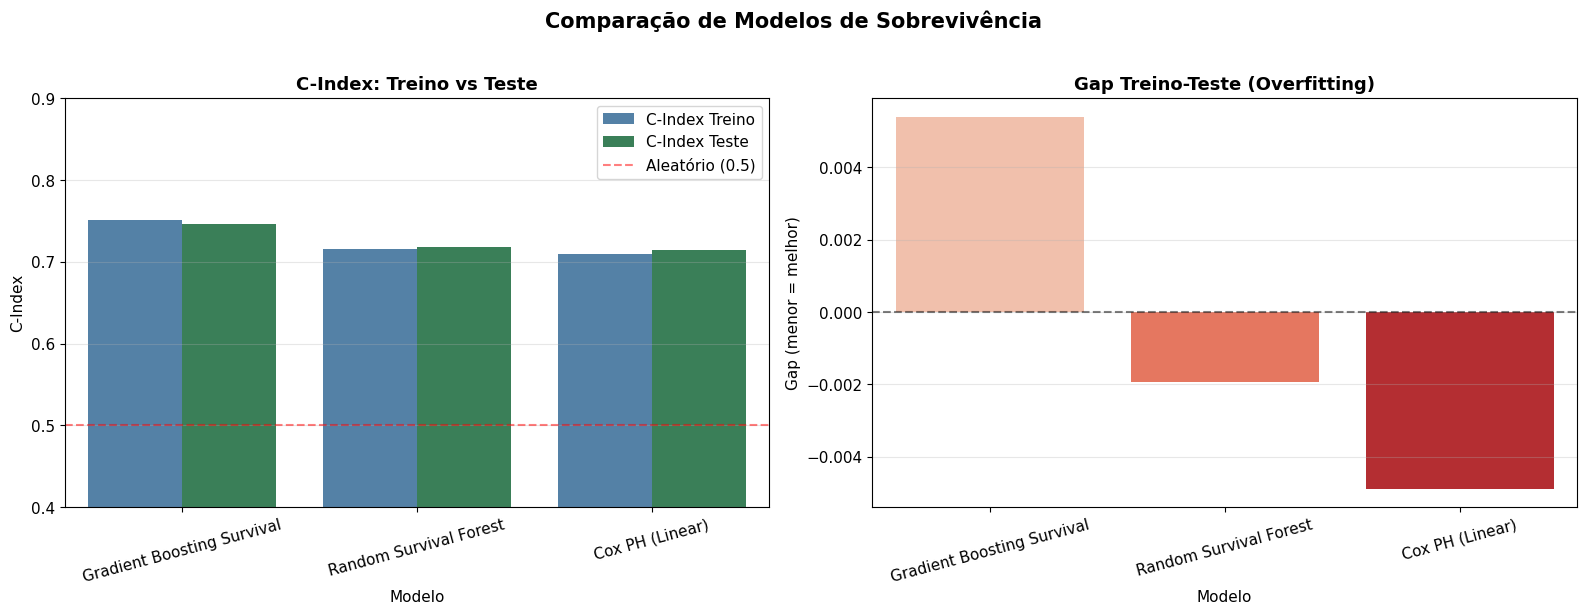

In [13]:
# Gráfico 1: C-Index Treino vs Teste
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_melted = df_comp.melt(id_vars='Modelo', value_vars=['C-Index Treino','C-Index Teste'], var_name='Split', value_name='C-Index')
sns.barplot(data=df_melted, x='Modelo', y='C-Index', hue='Split', palette={'C-Index Treino':'steelblue','C-Index Teste':'seagreen'}, ax=axes[0])
axes[0].axhline(0.5, ls='--', color='red', alpha=0.5, label='Aleatório (0.5)')
axes[0].set_title('C-Index: Treino vs Teste', fontsize=13, fontweight='bold')
axes[0].set_ylim(0.4, 0.9)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)

# Gap
sns.barplot(data=df_comp, x='Modelo', y='Gap', palette='Reds', ax=axes[1])
axes[1].axhline(0, ls='--', color='black', alpha=0.5)
axes[1].set_title('Gap Treino-Teste (Overfitting)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Gap (menor = melhor)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparação de Modelos de Sobrevivência', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

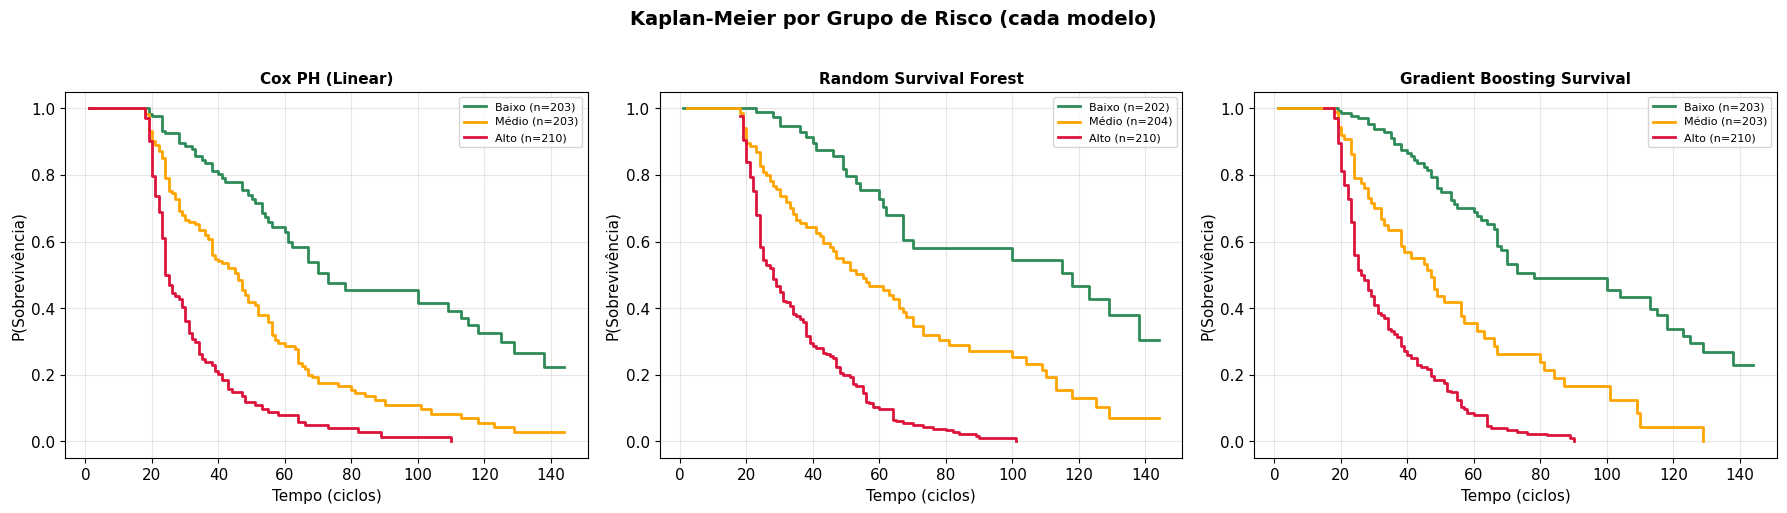

Quanto mais separadas as curvas, melhor o modelo discrimina!


In [14]:
# Gráfico 2: Kaplan-Meier por grupo de risco de cada modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nome, modelo) in enumerate(modelos_treinados.items()):
    risk = modelo.predict(X_test_s)
    tercis = np.percentile(risk, [33, 66])
    grupos = np.digitize(risk, tercis)

    for g, (label, cor) in enumerate(zip(['Baixo','Médio','Alto'],['seagreen','orange','crimson'])):
        mask = grupos == g
        if mask.sum() > 0:
            t, s = kaplan_meier_estimator(y_test['evento'][mask], y_test['duracao'][mask])
            axes[idx].step(t, s, where='post', lw=2, color=cor, label=f'{label} (n={mask.sum()})')

    axes[idx].set_title(nome, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Tempo (ciclos)')
    axes[idx].set_ylabel('P(Sobrevivência)')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Kaplan-Meier por Grupo de Risco (cada modelo)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Quanto mais separadas as curvas, melhor o modelo discrimina!')